In [1]:
import pandas as pd
from scipy import stats
import matplotlib.pyplot as plt
import numpy as np
import torch
from sklearn.preprocessing import StandardScaler
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, roc_auc_score, classification_report

import pyro
import pyro.distributions as dist
from pyro.infer import SVI, Trace_ELBO, Predictive
from pyro.optim import Adam, ClippedAdam
from pyro.infer.autoguide import AutoMultivariateNormal, AutoDiagonalNormal

c:\Users\annas\AppData\Local\Programs\Python\Python311\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


# 1. Small EDA

In [2]:
df_original=pd.read_csv("data/train.csv")
df_original.head()

,MONTH,DAY_OF_WEEK,DEP_DEL15,DEP_TIME_BLK,DISTANCE_GROUP,SEGMENT_NUMBER,CONCURRENT_FLIGHTS,NUMBER_OF_SEATS,CARRIER_NAME,AIRPORT_FLIGHTS_MONTH,...,PREVIOUS_AIRPORT,PRCP,SNOW,SNWD,TMAX,AWND,CARRIER_HISTORICAL,DEP_AIRPORT_HIST,DAY_HISTORICAL,DEP_BLOCK_HIST
0,7,7,0,1500-1559,3,3,26,160,American Airlines Inc.,19534,...,Chicago O'Hare International,0.00,0.0,0.0,95.0,4.25,0.237709,0.273236,0.222538,0.255479
1,4,1,0,1300-1359,4,4,63,50,SkyWest Airlines Inc.,18788,...,El Paso International,0.00,0.0,0.0,71.0,11.41,0.154651,0.121849,0.237972,0.197503
2,11,4,0,0001-0559,2,1,3,76,American Eagle Airlines Inc.,1148,...,NONE,0.00,0.0,0.0,54.0,0.45,0.117559,0.187867,0.139886,0.060327
3,3,2,0,1500-1559,7,5,14,143,Southwest Airlines Co.,7612,...,San Jose International,0.00,0.0,0.0,64.0,8.05,0.204389,0.141446,0.132868,0.202037
4,7,3,0,0800-0859,1,2,85,50,American Eagle Airlines Inc.,29376,...,Cincinnati/Northern Kentucky International,0.01,0.0,0.0,94.0,10.51,0.203263,0.193761,0.203027,0.113050


In [3]:
df_original = df_original.rename(columns={"DEP_DEL15": "DELAY", "AWND":"WIND"})

print("Missing values per column:")
print(df_original.isnull().sum())

Missing values per column:
MONTH                            0
DAY_OF_WEEK                      0
DELAY                            0
DEP_TIME_BLK                     0
DISTANCE_GROUP                   0
SEGMENT_NUMBER                   0
CONCURRENT_FLIGHTS               0
NUMBER_OF_SEATS                  0
CARRIER_NAME                     0
AIRPORT_FLIGHTS_MONTH            0
AIRLINE_FLIGHTS_MONTH            0
AIRLINE_AIRPORT_FLIGHTS_MONTH    0
AVG_MONTHLY_PASS_AIRPORT         0
AVG_MONTHLY_PASS_AIRLINE         0
FLT_ATTENDANTS_PER_PASS          0
GROUND_SERV_PER_PASS             0
PLANE_AGE                        0
DEPARTING_AIRPORT                0
LATITUDE                         0
LONGITUDE                        0
PREVIOUS_AIRPORT                 0
PRCP                             0
SNOW                             0
SNWD                             0
TMAX                             0
WIND                             0
CARRIER_HISTORICAL               0
DEP_AIRPORT_HIST            

Compute correlations between non categorical variables and delay (target)

               variable  correlation
0         DEP_BLOCK_ENC       0.1672
1        SEGMENT_NUMBER       0.1173
2                  PRCP       0.0801
3                  WIND       0.0509
8        DISTANCE_GROUP       0.0160
7       NUMBER_OF_SEATS       0.0117
4    CONCURRENT_FLIGHTS       0.0094
6             PLANE_AGE       0.0063
5  GROUND_SERV_PER_PASS      -0.0166


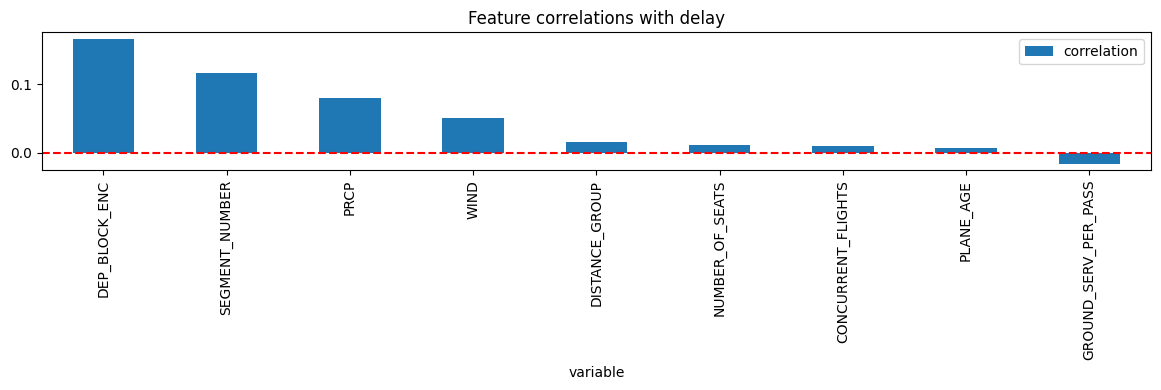

In [4]:
df_original["DEP_BLOCK_ENC"] = pd.Categorical(df_original["DEP_TIME_BLK"]).codes

cols_to_check = [
    "DEP_BLOCK_ENC",
    "SEGMENT_NUMBER", 
    "PRCP",
    "WIND",
    "CONCURRENT_FLIGHTS",
    "GROUND_SERV_PER_PASS",
    "PLANE_AGE",
    "NUMBER_OF_SEATS",
    "DISTANCE_GROUP",
]

results = []
for col in cols_to_check:
    corr = df_original["DELAY"].corr(df_original[col])
    results.append({"variable": col, "correlation": round(corr, 4)})

results_df = pd.DataFrame(results).sort_values("correlation", ascending=False)
print(results_df)

results_df.plot(x="variable", y="correlation", kind="bar", figsize=(12, 4))
plt.axhline(0, color="red", linestyle="--")
plt.title("Feature correlations with delay")
plt.tight_layout()
plt.show()

The most correlated to delay are Departure Block, Segment Number, Rain, Previous Airport Delay Rate and Wind.

Plot the mean delay value for each carrier, to see if it varies between carriers.

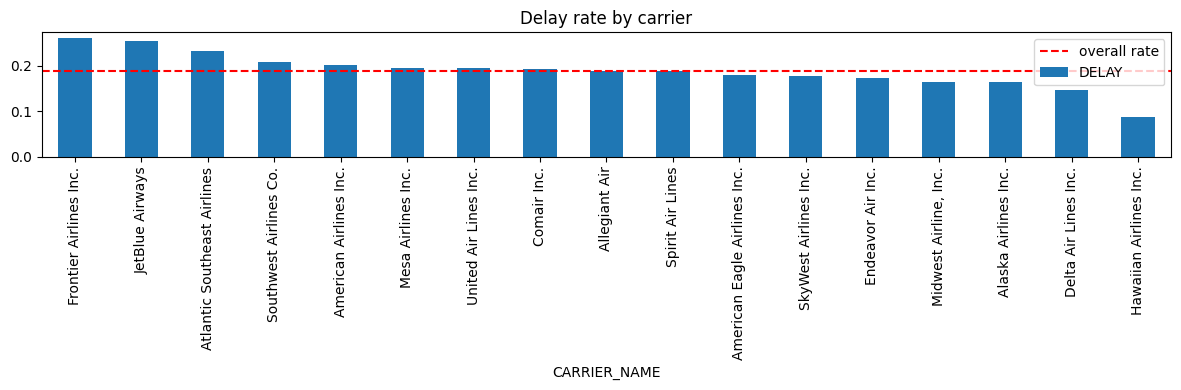

In [5]:
df_original.groupby("CARRIER_NAME")["DELAY"].mean().sort_values(ascending=False).plot(kind="bar", figsize=(12,4))
plt.axhline(df_original["DELAY"].mean(), color="red", linestyle="--", label="overall rate")
plt.title("Delay rate by carrier")
plt.legend()
plt.tight_layout()
plt.show()

There is a clear difference between the top mean delayed carrier and the low mean delayed carrier, so we can consider carrier as have some influence on delay

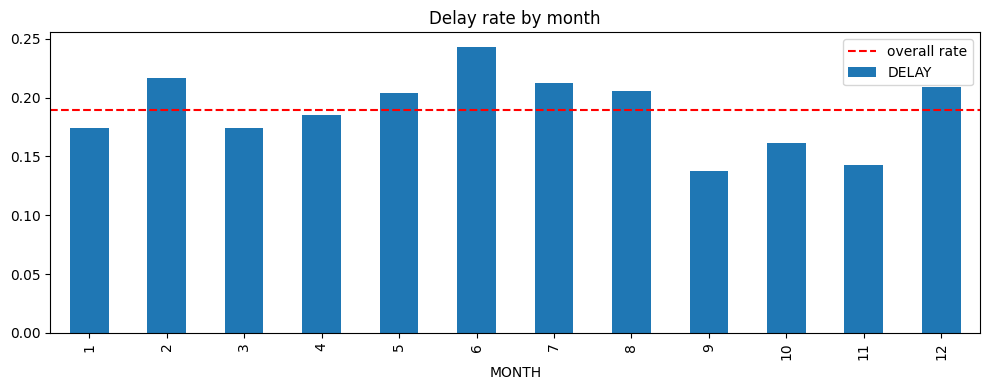

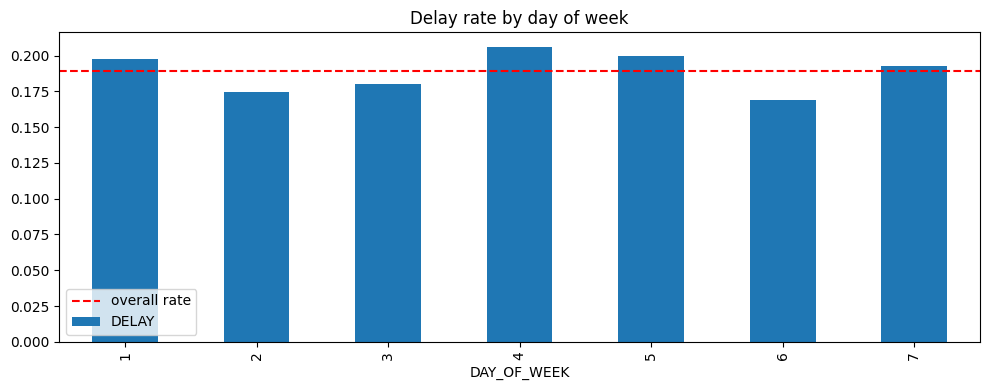

In [6]:
df_original.groupby("MONTH")["DELAY"].mean().sort_index().plot(kind="bar", figsize=(10,4))
plt.axhline(df_original["DELAY"].mean(), color="red", linestyle="--", label="overall rate")
plt.title("Delay rate by month")
plt.legend()
plt.tight_layout()
plt.show()

df_original.groupby("DAY_OF_WEEK")["DELAY"].mean().sort_index().plot(kind="bar", figsize=(10,4))
plt.axhline(df_original["DELAY"].mean(), color="red", linestyle="--", label="overall rate")
plt.title("Delay rate by day of week")
plt.legend()
plt.tight_layout()
plt.show()

The delay rate clearly varies per month but not per day of week.

In [7]:
# compute delay rate per airport from departing airport values
airport_delay_rate = df_original.groupby("DEPARTING_AIRPORT")["DELAY"].mean()
global_median = airport_delay_rate.median()

# map to each flight
df_original["DEPARTING_AIRPORT_DELAY_RATE"] = df_original["DEPARTING_AIRPORT"].map(airport_delay_rate)
df_original["PREV_AIRPORT_DELAY_RATE"] = df_original["PREVIOUS_AIRPORT"].map(airport_delay_rate)

print("Missing values:")
print(f"DEPARTING_AIRPORT_DELAY_RATE: {df_original['DEPARTING_AIRPORT_DELAY_RATE'].isnull().sum()}")
print(f"PREV_AIRPORT_DELAY_RATE: {df_original['PREV_AIRPORT_DELAY_RATE'].isnull().sum()}")

Missing values:
DEPARTING_AIRPORT_DELAY_RATE: 0
PREV_AIRPORT_DELAY_RATE: 1426830


In [8]:
# fill NaN with median
df_original["PREV_AIRPORT_DELAY_RATE"] = df_original["PREV_AIRPORT_DELAY_RATE"].fillna(global_median)

print("\nCorrelations with delay:")
print(f"DEPARTING_AIRPORT_DELAY_RATE: {df_original['DELAY'].corr(df_original['DEPARTING_AIRPORT_DELAY_RATE']):.4f}")
print(f"PREV_AIRPORT_DELAY_RATE: {df_original['DELAY'].corr(df_original['PREV_AIRPORT_DELAY_RATE']):.4f}")


Correlations with delay:
DEPARTING_AIRPORT_DELAY_RATE: 0.0826
PREV_AIRPORT_DELAY_RATE: 0.0795


The departing and previous airport delay rates also have some correlation with the delay

So we will keep the variables
 - departure block
 - segment number
 - rain
 - wind
 - month
 - carrier
 - delay rate of departing airport
 - delay rate of previous airport

Now we will check for collinearity between these variables

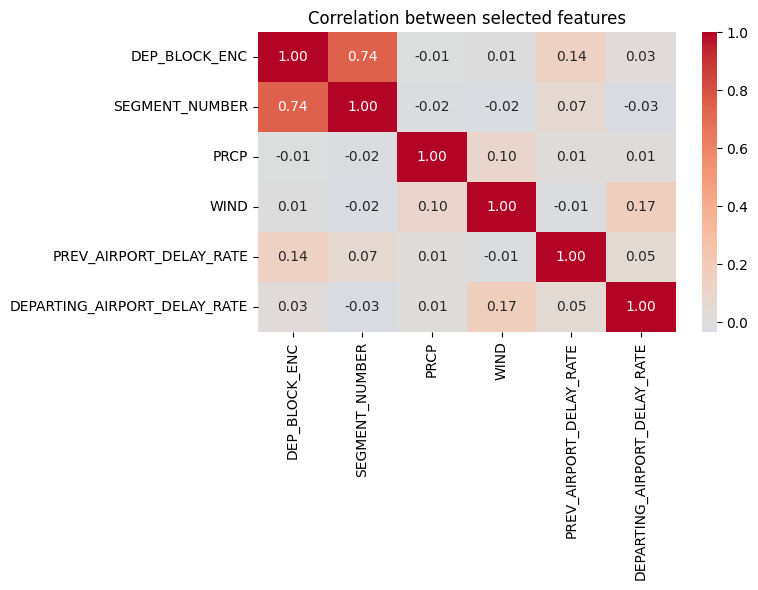

In [9]:
cols_selected = [
    "DEP_BLOCK_ENC",
    "SEGMENT_NUMBER",
    "PRCP",
    "WIND",
    "PREV_AIRPORT_DELAY_RATE",
    "DEPARTING_AIRPORT_DELAY_RATE",
]

corr_matrix = df_original[cols_selected].corr().round(3)

fig, ax = plt.subplots(figsize=(8, 6))
sns.heatmap(corr_matrix, annot=True, fmt=".2f", cmap="coolwarm", center=0, ax=ax)
plt.title("Correlation between selected features")
plt.tight_layout()
plt.show()

We will drop segment number bc it seems to encode the same info as departure block, and departure block has higher correlation with delay. 

Now we will look at month

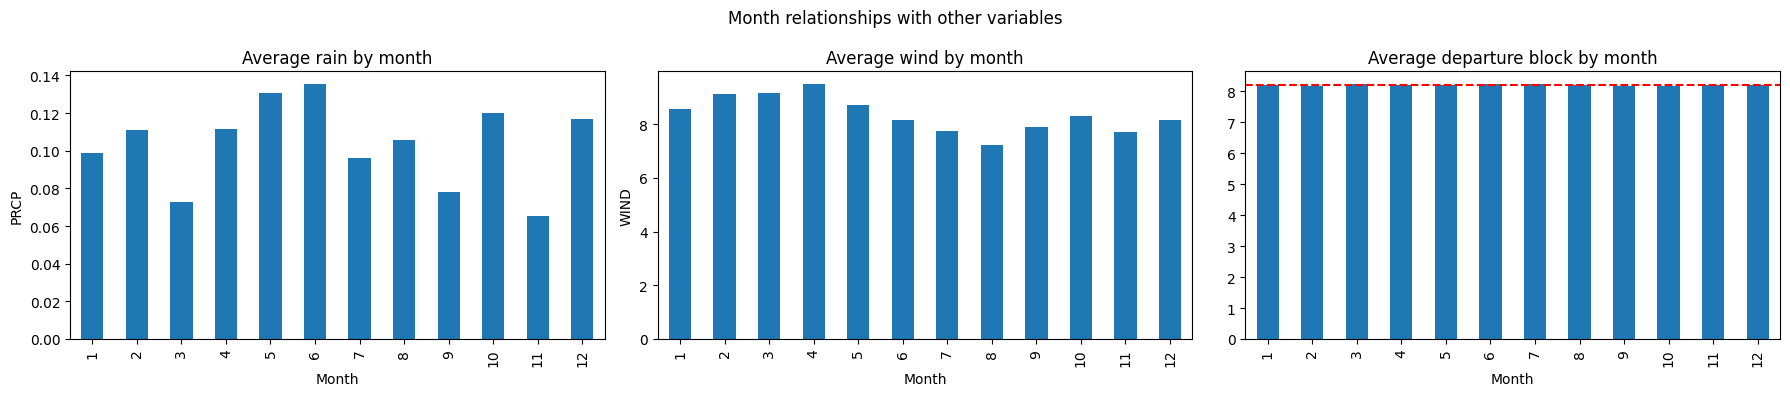

In [10]:
fig, axes = plt.subplots(1, 3, figsize=(18, 4))

# month vs rain
df_original.groupby("MONTH")["PRCP"].mean().sort_index().plot(kind="bar", ax=axes[0])
axes[0].set_title("Average rain by month")
axes[0].set_xlabel("Month")
axes[0].set_ylabel("PRCP")

# month vs wind
df_original.groupby("MONTH")["WIND"].mean().sort_index().plot(kind="bar", ax=axes[1])
axes[1].set_title("Average wind by month")
axes[1].set_xlabel("Month")
axes[1].set_ylabel("WIND")

# month vs departure block distribution
df_original.groupby("MONTH")["DEP_BLOCK_ENC"].mean().sort_index().plot(kind="bar", ax=axes[2])
axes[2].axhline(df_original["DEP_BLOCK_ENC"].mean(), color="red", linestyle="--")
axes[2].set_title("Average departure block by month")
axes[2].set_xlabel("Month")

plt.suptitle("Month relationships with other variables")
plt.tight_layout()
plt.show()

Wind does not vary that much per month, rain varies per month so we will keep both but keeping this in mind, departure block does not vary with month they are independent

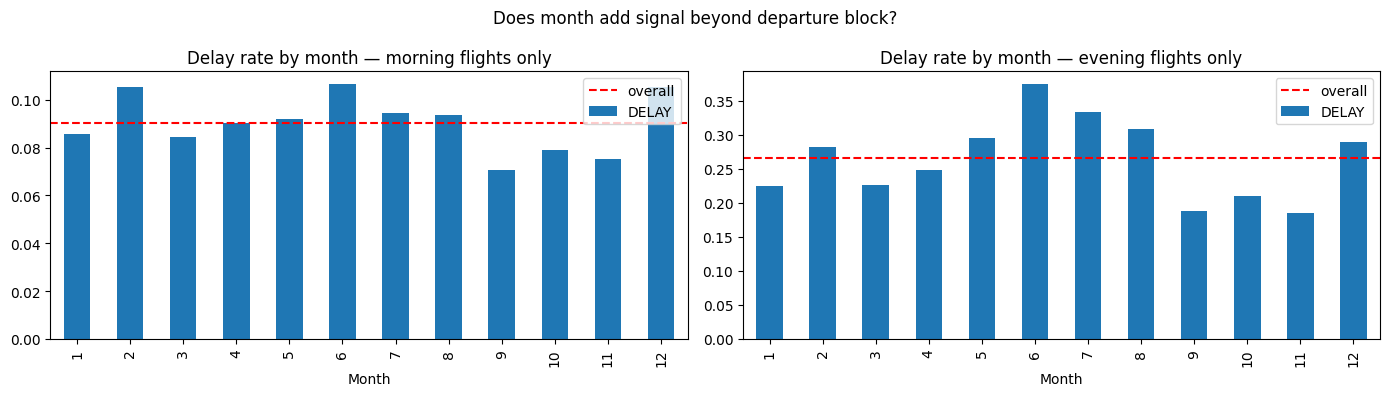

In [11]:
fig, axes = plt.subplots(1, 2, figsize=(14, 4))

# morning flights
morning = df_original[df_original["DEP_BLOCK_ENC"] <= 3]
morning.groupby("MONTH")["DELAY"].mean().sort_index().plot(kind="bar", ax=axes[0])
axes[0].axhline(morning["DELAY"].mean(), color="red", linestyle="--", label="overall")
axes[0].set_title("Delay rate by month — morning flights only")
axes[0].set_xlabel("Month")
axes[0].legend()

# evening flights
evening = df_original[df_original["DEP_BLOCK_ENC"] >= 14]
evening.groupby("MONTH")["DELAY"].mean().sort_index().plot(kind="bar", ax=axes[1])
axes[1].axhline(evening["DELAY"].mean(), color="red", linestyle="--", label="overall")
axes[1].set_title("Delay rate by month — evening flights only")
axes[1].set_xlabel("Month")
axes[1].legend()

plt.suptitle("Does month add signal beyond departure block?")
plt.tight_layout()
plt.show()

The pattern is the same regardless of time of the day so month clearly has some signal beyond departure block   

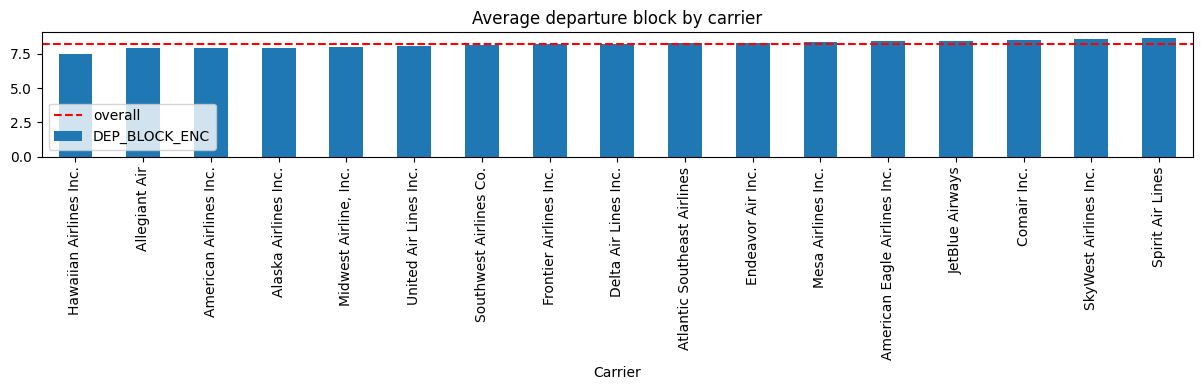

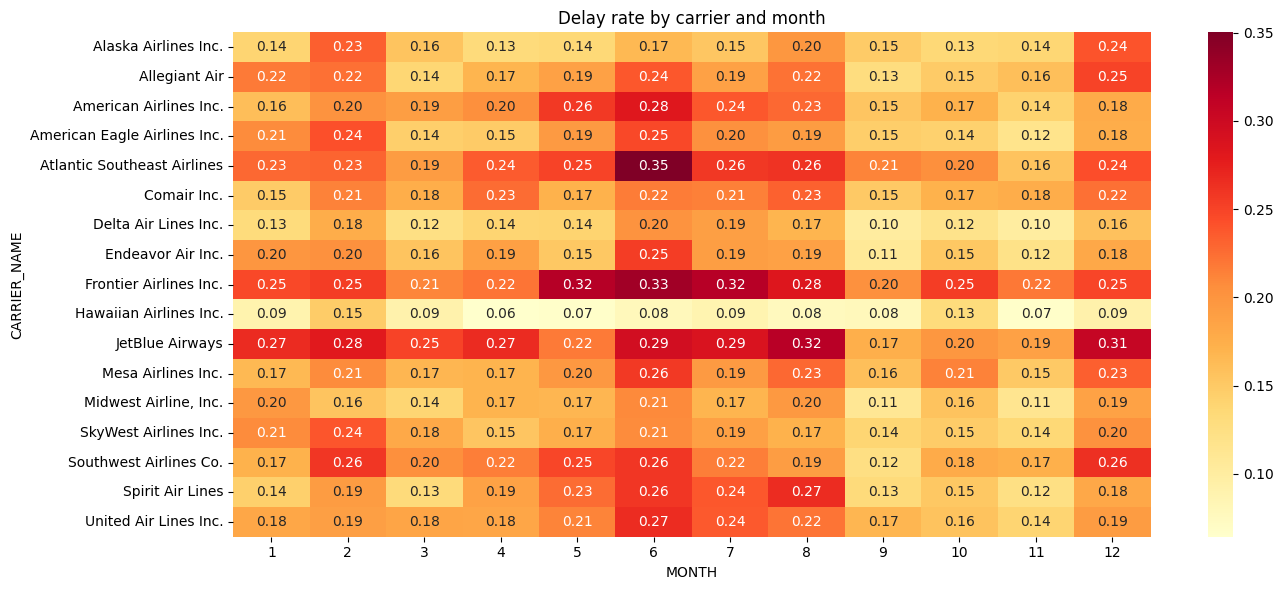

In [12]:
# carrier vs average dept block
fig, ax = plt.subplots(figsize=(12, 4))
df_original.groupby("CARRIER_NAME")["DEP_BLOCK_ENC"].mean().sort_values().plot(kind="bar", ax=ax)
ax.axhline(df_original["DEP_BLOCK_ENC"].mean(), color="red", linestyle="--", label="overall")
ax.set_title("Average departure block by carrier")
ax.set_xlabel("Carrier")
ax.legend()
plt.tight_layout()
plt.show()

# carrier delay rate by month 
fig, ax = plt.subplots(figsize=(14, 6))
carrier_month = df_original.groupby(["CARRIER_NAME", "MONTH"])["DELAY"].mean().unstack()
sns.heatmap(carrier_month, annot=True, fmt=".2f", cmap="YlOrRd", ax=ax)
ax.set_title("Delay rate by carrier and month")
plt.tight_layout()
plt.show()

In [13]:
# range of delay rates across months per carrier
carrier_month_range = carrier_month.max(axis=1) - carrier_month.min(axis=1)
print("Range of delay rates across months per carrier:")
print(carrier_month_range.sort_values(ascending=False))

Range of delay rates across months per carrier:
CARRIER_NAME
Atlantic Southeast Airlines     0.193315
Endeavor Air Inc.               0.145458
Spirit Air Lines                0.141932
JetBlue Airways                 0.141905
American Airlines Inc.          0.140213
Southwest Airlines Co.          0.139209
American Eagle Airlines Inc.    0.129402
Frontier Airlines Inc.          0.127370
United Air Lines Inc.           0.125395
Allegiant Air                   0.122078
Alaska Airlines Inc.            0.108379
Mesa Airlines Inc.              0.106755
SkyWest Airlines Inc.           0.102871
Delta Air Lines Inc.            0.099848
Midwest Airline, Inc.           0.097663
Comair Inc.                     0.083965
Hawaiian Airlines Inc.          0.083554
dtype: float64


So all carriers have the same average departure block meaning some dont operate more in some times of days than others, carrier and departure block are independent

While month has a global effect on all carriers, the magnitude varies. Atlantic Southeast seasonal range is 0.19 while Hawaiian is 0.08. This suggests a carrier-month interaction.

So 
- rain
- wind
- dept block
- month <br>

Go into delay <br>

- carrier baseline
- previous airport delay rate
- departing airport delay rate <br>

Go into stress


# 2. Download datasets

## Train

In [14]:
df_train = df_original[["DELAY", "CARRIER_NAME", "PRCP", "WIND", "MONTH", "DEP_TIME_BLK", "DEP_BLOCK_ENC", "PREV_AIRPORT_DELAY_RATE", "DEPARTING_AIRPORT_DELAY_RATE"]]
print(f"Number of observations: {len(df_train)}")
print(df_train.isna().sum())
df_train.head()

Number of observations: 4542343
DELAY                           0
CARRIER_NAME                    0
PRCP                            0
WIND                            0
MONTH                           0
DEP_TIME_BLK                    0
DEP_BLOCK_ENC                   0
PREV_AIRPORT_DELAY_RATE         0
DEPARTING_AIRPORT_DELAY_RATE    0
dtype: int64


,DELAY,CARRIER_NAME,PRCP,WIND,MONTH,DEP_TIME_BLK,DEP_BLOCK_ENC,PREV_AIRPORT_DELAY_RATE,DEPARTING_AIRPORT_DELAY_RATE
0,0,American Airlines Inc.,0.00,4.25,7,1500-1559,10,0.224594,0.195292
1,0,SkyWest Airlines Inc.,0.00,11.41,4,1300-1359,8,0.159366,0.225547
2,0,American Eagle Airlines Inc.,0.00,0.45,11,0001-0559,0,0.170699,0.163854
3,0,Southwest Airlines Co.,0.00,8.05,3,1500-1559,10,0.147617,0.172137
4,0,American Eagle Airlines Inc.,0.01,10.51,7,0800-0859,3,0.181550,0.224594


One hot encode month, carrier and departure time block
- January as reference
- Spirit Air Lines as reference (closest to the overall delay rate)
- 0001-0559 as reference

In [15]:
carrier_delay = df_original.groupby("CARRIER_NAME")["DELAY"].mean()
overall_rate = df_original["DELAY"].mean()

print(f"Overall delay rate: {overall_rate:.4f}")
print("\nCarrier delay rates vs overall:")
print((carrier_delay - overall_rate).abs().sort_values())

Overall delay rate: 0.1891

Carrier delay rates vs overall:
CARRIER_NAME
Spirit Air Lines                0.000590
Allegiant Air                   0.000611
Comair Inc.                     0.004844
United Air Lines Inc.           0.006139
Mesa Airlines Inc.              0.006304
American Eagle Airlines Inc.    0.009451
SkyWest Airlines Inc.           0.010806
American Airlines Inc.          0.011891
Endeavor Air Inc.               0.014819
Southwest Airlines Co.          0.019898
Midwest Airline, Inc.           0.024863
Alaska Airlines Inc.            0.025160
Delta Air Lines Inc.            0.042759
Atlantic Southeast Airlines     0.043935
JetBlue Airways                 0.064829
Frontier Airlines Inc.          0.071501
Hawaiian Airlines Inc.          0.102194
Name: DELAY, dtype: float64


In [16]:
month_dummies = pd.get_dummies(df_train["MONTH"], prefix="month")
month_columns = month_dummies.columns.tolist()
# drop January as reference
month_columns_model = month_columns[1:]  

carrier_dummies = pd.get_dummies(df_train["CARRIER_NAME"], prefix="carrier")
carrier_columns = carrier_dummies.columns.tolist()
carrier_columns_model = [c for c in carrier_columns if "Spirit" not in c]

dpt_dummies = pd.get_dummies(df_train["DEP_TIME_BLK"], prefix="dep_block")
dpt_columns = dpt_dummies.columns.tolist()
# drops 0001-0559 as reference
dpt_columns_model = dpt_columns[1:]

df_train = pd.concat([df_train,carrier_dummies[carrier_columns_model],dpt_dummies[dpt_columns_model],month_dummies[month_columns_model]], axis=1)

## Train sample

The dataset is very large, so we sample it and verify that the sample is still representative of the full set.

In [17]:
df_train["STRAT_KEY"] = (df_train["DELAY"].astype(str) + "_" + df_train["CARRIER_NAME"])

df_sample, _ = train_test_split(df_train, train_size=0.1, stratify=df_train["STRAT_KEY"], random_state=42)
df_sample = df_sample.drop(columns=["STRAT_KEY"])
df_train  = df_train.drop(columns=["STRAT_KEY"])

print(df_sample.shape)

# verify one hot columns are present — use model columns not full columns
print("Carrier columns present:", all(col in df_sample.columns for col in carrier_columns_model))
print("DPT columns present:", all(col in df_sample.columns for col in dpt_columns_model))
print("Month columns present:", all(col in df_sample.columns for col in month_columns_model))

(454234, 54)
Carrier columns present: True
DPT columns present: True
Month columns present: True


In [18]:
print("=== Delay rate ===")
print(f"Full:   {df_train['DELAY'].mean():.4f}")
print(f"Sample: {df_sample['DELAY'].mean():.4f}")

print("\n=== Carrier distribution ===")
print(pd.DataFrame({
    "full":   df_train["CARRIER_NAME"].value_counts(normalize=True).round(4),
    "sample": df_sample["CARRIER_NAME"].value_counts(normalize=True).round(4)
}))

print("\n=== Month distribution ===")
print(pd.DataFrame({
    "full":   df_train["MONTH"].value_counts(normalize=True).sort_index().round(4),
    "sample": df_sample["MONTH"].value_counts(normalize=True).sort_index().round(4)
}))

print("\n=== Departure block distribution ===")
print(pd.DataFrame({
    "full":   df_train["DEP_TIME_BLK"].value_counts(normalize=True).sort_index().round(4),
    "sample": df_sample["DEP_TIME_BLK"].value_counts(normalize=True).sort_index().round(4)
}))

print("\n=== Continuous variables ===")
for col in ["PRCP", "WIND", "PREV_AIRPORT_DELAY_RATE", "DEPARTING_AIRPORT_DELAY_RATE"]:
    if col in df_train.columns:
        print(f"\n{col}:")
        print(f"  full   — mean: {df_train[col].mean():.4f}, std: {df_train[col].std():.4f}")
        print(f"  sample — mean: {df_sample[col].mean():.4f}, std: {df_sample[col].std():.4f}")

print("\n=== Missing carriers or departure blocks ===")
print("Carriers in full not in sample:", 
      set(df_train["CARRIER_NAME"].unique()) - set(df_sample["CARRIER_NAME"].unique()))
print("Months in full not in sample:", 
      set(df_train["MONTH"].unique()) - set(df_sample["MONTH"].unique()))
print("Dep blocks in full not in sample:", 
      set(df_train["DEP_TIME_BLK"].unique()) - set(df_sample["DEP_TIME_BLK"].unique()))

=== Delay rate ===
Full:   0.1891
Sample: 0.1891

=== Carrier distribution ===
                                full  sample
CARRIER_NAME                                
Southwest Airlines Co.        0.1997  0.1997
Delta Air Lines Inc.          0.1447  0.1447
American Airlines Inc.        0.1393  0.1393
United Air Lines Inc.         0.0926  0.0926
SkyWest Airlines Inc.         0.0901  0.0901
Midwest Airline, Inc.         0.0463  0.0463
JetBlue Airways               0.0415  0.0415
Alaska Airlines Inc.          0.0369  0.0369
American Eagle Airlines Inc.  0.0353  0.0353
Comair Inc.                   0.0338  0.0338
Endeavor Air Inc.             0.0314  0.0314
Spirit Air Lines              0.0292  0.0292
Mesa Airlines Inc.            0.0273  0.0273
Frontier Airlines Inc.        0.0187  0.0187
Atlantic Southeast Airlines   0.0152  0.0152
Hawaiian Airlines Inc.        0.0115  0.0115
Allegiant Air                 0.0065  0.0065

=== Month distribution ===
         full  sample
MONTH           

### Weather data

In [19]:
weather_scaler = StandardScaler()
df_sample["PRCP_LOG"] = np.log1p(df_sample["PRCP"])  
X_weather_train = weather_scaler.fit_transform(df_sample[["PRCP_LOG", "WIND"]])

### Stress data

In [20]:
# standardize only continuous stress variables
cont_stress_1 = ["PREV_AIRPORT_DELAY_RATE", "DEPARTING_AIRPORT_DELAY_RATE"]
cont_scaler1 = StandardScaler()
X_stress_cont1 = cont_scaler1.fit_transform(df_sample[cont_stress_1].values)

X_stress_carrier = df_sample[carrier_columns_model].values
X_stress_train1 = np.concatenate([X_stress_carrier, X_stress_cont1], axis=1)

### Departure block time data

In [21]:
X_dept = df_sample[dpt_columns_model].values

### Month data

In [22]:
X_month = df_sample[month_columns_model].values

### Tensor data

In [23]:
X_weather_train = torch.tensor(X_weather_train, dtype=torch.float32)
X_stress_train1 = torch.tensor(X_stress_train1, dtype=torch.float32)
X_dept_train = torch.tensor(X_dept, dtype=torch.float32)
X_month_train = torch.tensor(X_month, dtype=torch.float32)
y_train = torch.tensor(df_sample["DELAY"].values, dtype=torch.float32)

print("X_weather_train:", X_weather_train.shape)   # (N, 2)
print("X_stress_train1:", X_stress_train1.shape)   # (N, 18) — 16 carriers + 2 airport rates
print("X_dept_train:",   X_dept_train.shape)        # (N, 18) — 18 departure blocks
print("X_month_train:",  X_month_train.shape)       # (N, 11) — 11 months
print("y_train:",        y_train.shape)             # (N

X_weather_train: torch.Size([454234, 2])
X_stress_train1: torch.Size([454234, 18])
X_dept_train: torch.Size([454234, 18])
X_month_train: torch.Size([454234, 11])
y_train: torch.Size([454234])


## Test

In [24]:
df_test=pd.read_csv("data/test.csv")
df_test.head()

,MONTH,DAY_OF_WEEK,DEP_DEL15,DEP_TIME_BLK,DISTANCE_GROUP,SEGMENT_NUMBER,CONCURRENT_FLIGHTS,NUMBER_OF_SEATS,CARRIER_NAME,AIRPORT_FLIGHTS_MONTH,...,PREVIOUS_AIRPORT,PRCP,SNOW,SNWD,TMAX,AWND,CARRIER_HISTORICAL,DEP_AIRPORT_HIST,DAY_HISTORICAL,DEP_BLOCK_HIST
0,4,6,0,1000-1059,3,3,5,110,Delta Air Lines Inc.,6837,...,Atlanta Municipal,0.0,0.0,0.0,64.0,13.87,0.139558,0.180307,0.177124,0.147773
1,3,2,0,1000-1059,2,2,31,50,Endeavor Air Inc.,14450,...,Bangor International,0.0,0.0,0.0,48.0,12.08,0.155571,0.187883,0.132868,0.156045
2,2,5,0,1000-1059,8,2,37,173,United Air Lines Inc.,16530,...,Los Angeles International,0.0,0.0,0.0,54.0,10.07,0.189496,0.240316,0.236965,0.187484
3,4,6,0,0900-0959,11,2,37,181,Alaska Airlines Inc.,17522,...,Portland International,0.0,0.0,0.0,64.0,7.38,0.132326,0.112840,0.177124,0.135374
4,8,7,0,0900-0959,1,2,27,143,Southwest Airlines Co.,14220,...,Spokane International,0.0,0.0,0.0,104.0,4.92,0.192550,0.123487,0.196519,0.138067


In [25]:
df_test = df_test.rename(columns={"DEP_DEL15": "DELAY", "AWND":"WIND"})

print("Missing values per column:")
print(df_test.isnull().sum())

Missing values per column:
MONTH                            0
DAY_OF_WEEK                      0
DELAY                            0
DEP_TIME_BLK                     0
DISTANCE_GROUP                   0
SEGMENT_NUMBER                   0
CONCURRENT_FLIGHTS               0
NUMBER_OF_SEATS                  0
CARRIER_NAME                     0
AIRPORT_FLIGHTS_MONTH            0
AIRLINE_FLIGHTS_MONTH            0
AIRLINE_AIRPORT_FLIGHTS_MONTH    0
AVG_MONTHLY_PASS_AIRPORT         0
AVG_MONTHLY_PASS_AIRLINE         0
FLT_ATTENDANTS_PER_PASS          0
GROUND_SERV_PER_PASS             0
PLANE_AGE                        0
DEPARTING_AIRPORT                0
LATITUDE                         0
LONGITUDE                        0
PREVIOUS_AIRPORT                 0
PRCP                             0
SNOW                             0
SNWD                             0
TMAX                             0
WIND                             0
CARRIER_HISTORICAL               0
DEP_AIRPORT_HIST            

In [26]:
# use median from training
df_test["DEPARTING_AIRPORT_DELAY_RATE"] = df_test["DEPARTING_AIRPORT"].map(airport_delay_rate).fillna(global_median)
df_test["PREV_AIRPORT_DELAY_RATE"]      = df_test["PREVIOUS_AIRPORT"].map(airport_delay_rate).fillna(global_median)

# check
print("Missing values after filling:")
print(f"DEPARTING_AIRPORT_DELAY_RATE: {df_test['DEPARTING_AIRPORT_DELAY_RATE'].isnull().sum()}")
print(f"PREV_AIRPORT_DELAY_RATE:      {df_test['PREV_AIRPORT_DELAY_RATE'].isnull().sum()}")

Missing values after filling:
DEPARTING_AIRPORT_DELAY_RATE: 0
PREV_AIRPORT_DELAY_RATE:      0


In [27]:
# one hot encode test using training column lists
carrier_dummies_test = pd.get_dummies(df_test["CARRIER_NAME"], prefix="carrier")
dpt_dummies_test = pd.get_dummies(df_test["DEP_TIME_BLK"], prefix="dep_block")
month_dummies_test = pd.get_dummies(df_test["MONTH"], prefix="month")

# reindex to match training columns exactly — fills missing with 0
carrier_dummies_test = carrier_dummies_test.reindex(columns=carrier_columns_model, fill_value=0)
dpt_dummies_test = dpt_dummies_test.reindex(columns=dpt_columns_model, fill_value=0)
month_dummies_test = month_dummies_test.reindex(columns=month_columns_model, fill_value=0)

# add to df_test
df_test = pd.concat([df_test, carrier_dummies_test, dpt_dummies_test, month_dummies_test], axis=1)

# verify
print("Carrier columns match:", all(col in df_test.columns for col in carrier_columns_model))
print("Dept columns match:",    all(col in df_test.columns for col in dpt_columns_model))
print("Month columns match:",   all(col in df_test.columns for col in month_columns_model))

Carrier columns match: True
Dept columns match: True
Month columns match: True


In [28]:
df_test["PRCP_LOG"] = np.log1p(df_test["PRCP"])
X_weather_test = weather_scaler.transform(df_test[["PRCP_LOG", "WIND"]])

In [29]:
# standardize only continuous stress variables
cont_stress_1 = ["PREV_AIRPORT_DELAY_RATE", "DEPARTING_AIRPORT_DELAY_RATE"]
X_stress_cont1 = cont_scaler1.transform(df_test[cont_stress_1].values)

X_stress_carrier = df_test[carrier_columns_model].values
X_stress_test1 = np.concatenate([X_stress_carrier, X_stress_cont1], axis=1)

In [30]:
X_dept_test = df_test[dpt_columns_model].values

In [31]:
X_month_test = df_test[month_columns_model].values

In [32]:
X_weather_test = torch.tensor(X_weather_test, dtype=torch.float32)
X_stress_test1 = torch.tensor(X_stress_test1, dtype=torch.float32)
X_dept_test = torch.tensor(X_dept_test, dtype=torch.float32)
X_month_test = torch.tensor(X_month_test, dtype=torch.float32)
y_test = torch.tensor(df_test["DELAY"].values, dtype=torch.float32)

print("X_weather_test:", X_weather_test.shape)   # (N_test, 2)
print("X_stress_test1:", X_stress_test1.shape)   # (N_test, 18)
print("X_dept_test:",    X_dept_test.shape)       # (N_test, 18)
print("X_month_test:",   X_month_test.shape)      # (N_test, 11)
print("y_test:",         y_test.shape)

print("\nShape consistency checks:")
print("Stress cols match:", X_stress_test1.shape[1] == X_stress_train1.shape[1])
print("Weather cols match:", X_weather_test.shape[1] == X_weather_train.shape[1])
print("Dept cols match:", X_dept_test.shape[1] == X_dept_train.shape[1])
print("Month cols match:", X_month_test.shape[1] == X_month_train.shape[1])

X_weather_test: torch.Size([1946719, 2])
X_stress_test1: torch.Size([1946719, 18])
X_dept_test: torch.Size([1946719, 18])
X_month_test: torch.Size([1946719, 11])
y_test: torch.Size([1946719])

Shape consistency checks:
Stress cols match: True
Weather cols match: True
Dept cols match: True
Month cols match: True


# 3. Model 1

In [33]:
def model1(X_stress, X_weather, X_dept, X_month, y):

    n_stress = X_stress.shape[1]   # 18 — 16 carriers + 2 airport rates
    n_weather = X_weather.shape[1]  # 2  — rain, wind
    n_dept = X_dept.shape[1]     # 18 — departure blocks
    n_month = X_month.shape[1]    # 11 — months
    n_delay = n_weather + n_dept + n_month + 1  # +1 for stress

    # stress priors
    w = pyro.sample("w", dist.Normal(torch.zeros(n_stress), 
                                     torch.ones(n_stress)).to_event(1))
    sigma_stress = pyro.sample("sigma_stress", dist.HalfNormal(1.0))

    # delay priors
    beta = pyro.sample("beta", dist.Normal(torch.zeros(n_delay), 
                                           torch.ones(n_delay)).to_event(1))
    bias = pyro.sample("bias", dist.Normal(0., 1.))

    with pyro.plate("flights", X_stress.shape[0]):

        # stress mean — linear combination of carrier + airport rates
        mu_stress = torch.matmul(X_stress, w.T if w.dim() > 1 else w.unsqueeze(-1)).squeeze(-1)
        stress = pyro.sample("stress", dist.Normal(mu_stress, sigma_stress))

        # delay logits — rain, wind, departure blocks, months, stress
        logits = (
            (X_weather * beta[..., 0:n_weather]).sum(dim=-1) +
            (X_dept    * beta[..., n_weather:n_weather+n_dept]).sum(dim=-1) +
            (X_month   * beta[..., n_weather+n_dept:n_weather+n_dept+n_month]).sum(dim=-1) +
            beta[..., -1] * stress +
            bias
        )

        obs = pyro.sample("obs", dist.Bernoulli(logits=logits), obs=y)

    return obs

In [34]:
pyro.clear_param_store()
torch.manual_seed(42)
pyro.set_rng_seed(42)

guide1 = AutoDiagonalNormal(model1)

# setup
adam_params = {"lr": 0.001}
optimizer = ClippedAdam(adam_params)
elbo = Trace_ELBO(num_particles=1)
svi = SVI(model1, guide1, optimizer, loss=elbo)

n_steps = 5000

losses1 = []
for step in range(n_steps):
    loss = svi.step(X_stress_train1, X_weather_train, X_dept_train, X_month_train, y_train)
    losses1.append(loss)
    if step % 1000 == 0:
        print(f"[{step}] loss: {loss:.1f}")

[0] loss: 1117004.2
[1000] loss: 258324.6
[2000] loss: 215536.0
[3000] loss: 211122.0
[4000] loss: 209782.3


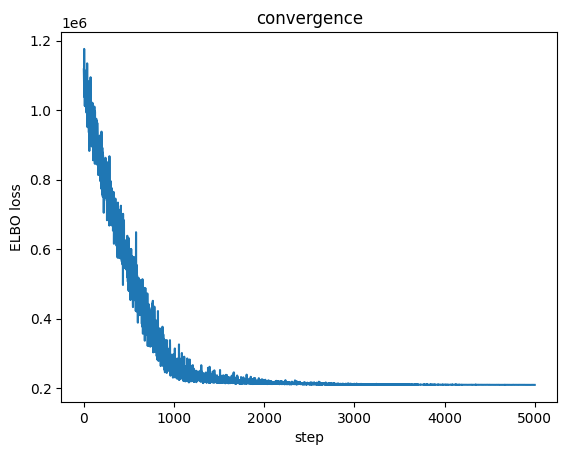

: 

In [ ]:
plt.plot(losses1)
plt.xlabel("step")
plt.ylabel("ELBO loss")
plt.title("convergence")
plt.show()

In [ ]:
predictive1 = Predictive(model1, guide=guide1, num_samples=1000)
samples1 = predictive1(X_stress_train1, X_weather_train, X_dept_train, X_month_train, None)

# extract samples
w_samples = samples1["w"].detach().squeeze(1).numpy()     # (1000, 18)
beta_samples = samples1["beta"].detach().squeeze(1).numpy()  # (1000, 32)
bias_samples = samples1["bias"].detach().squeeze(1).numpy()  # (1000,)

# stress weights
stress_cols1 = carrier_columns_model + ["PREV_AIRPORT_DELAY_RATE", "DEPARTING_AIRPORT_DELAY_RATE"]
print("=== Stress weights ===")
for i, col in enumerate(stress_cols1):
    print(f"  w_{col}: {w_samples[:, i].mean():.4f} ± {w_samples[:, i].std():.4f}")

# delay weights
n_weather = X_weather_train.shape[1]   # 2
n_dept = X_dept_train.shape[1]       # 18
n_month = X_month_train.shape[1]      # 11

print("\n=== Delay weights ===")
print(f"beta_rain:   {beta_samples[:, 0].mean():.4f} ± {beta_samples[:, 0].std():.4f}")
print(f"beta_wind:   {beta_samples[:, 1].mean():.4f} ± {beta_samples[:, 1].std():.4f}")

print("\nDeparture blocks:")
for i, col in enumerate(dpt_columns_model):
    print(f"  {col}: {beta_samples[:, n_weather+i].mean():.4f} ± {beta_samples[:, n_weather+i].std():.4f}")

print("\nMonths:")
for i, col in enumerate(month_columns_model):
    print(f"  {col}: {beta_samples[:, n_weather+n_dept+i].mean():.4f} ± {beta_samples[:, n_weather+n_dept+i].std():.4f}")

print(f"\nbeta_stress: {beta_samples[:, -1].mean():.4f} ± {beta_samples[:, -1].std():.4f}")
print(f"bias:        {bias_samples.mean():.4f} ± {bias_samples.std():.4f}")

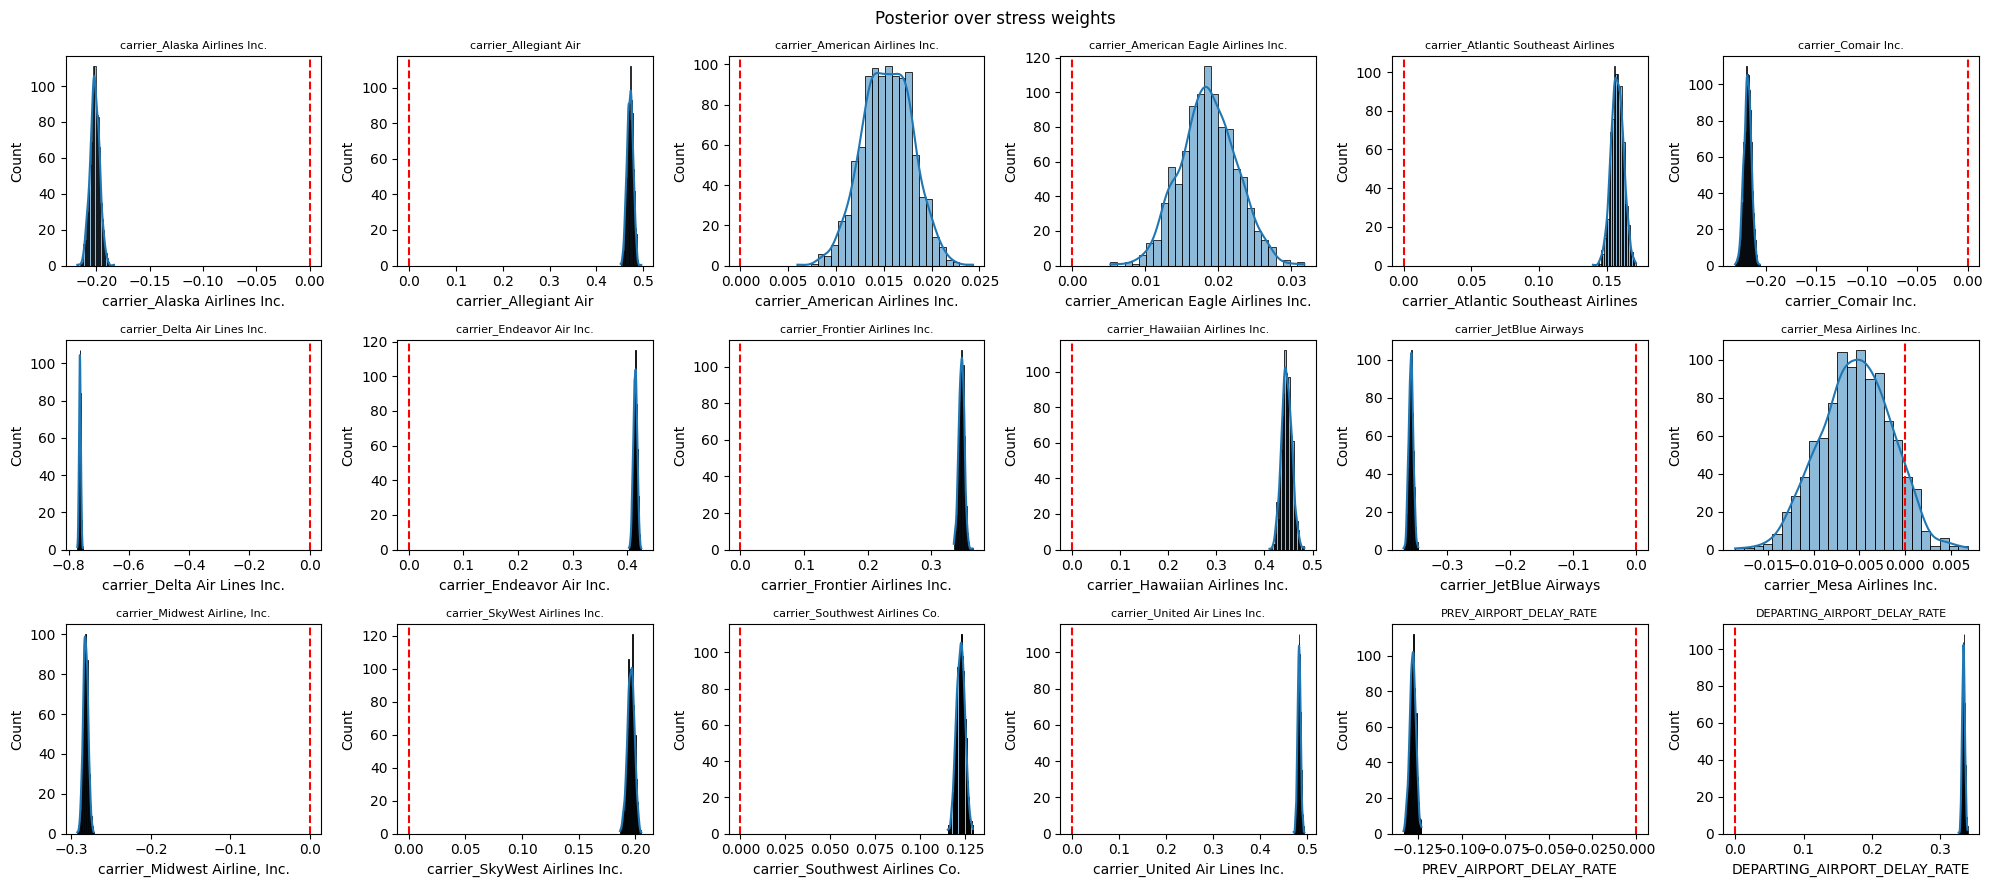

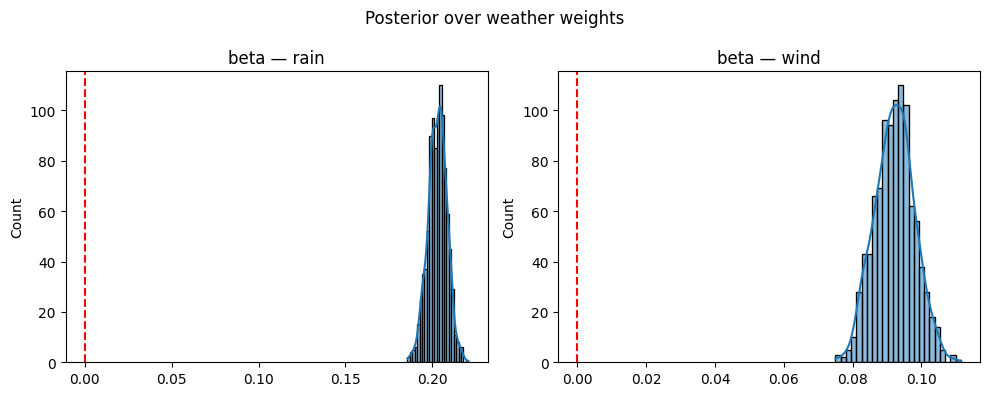

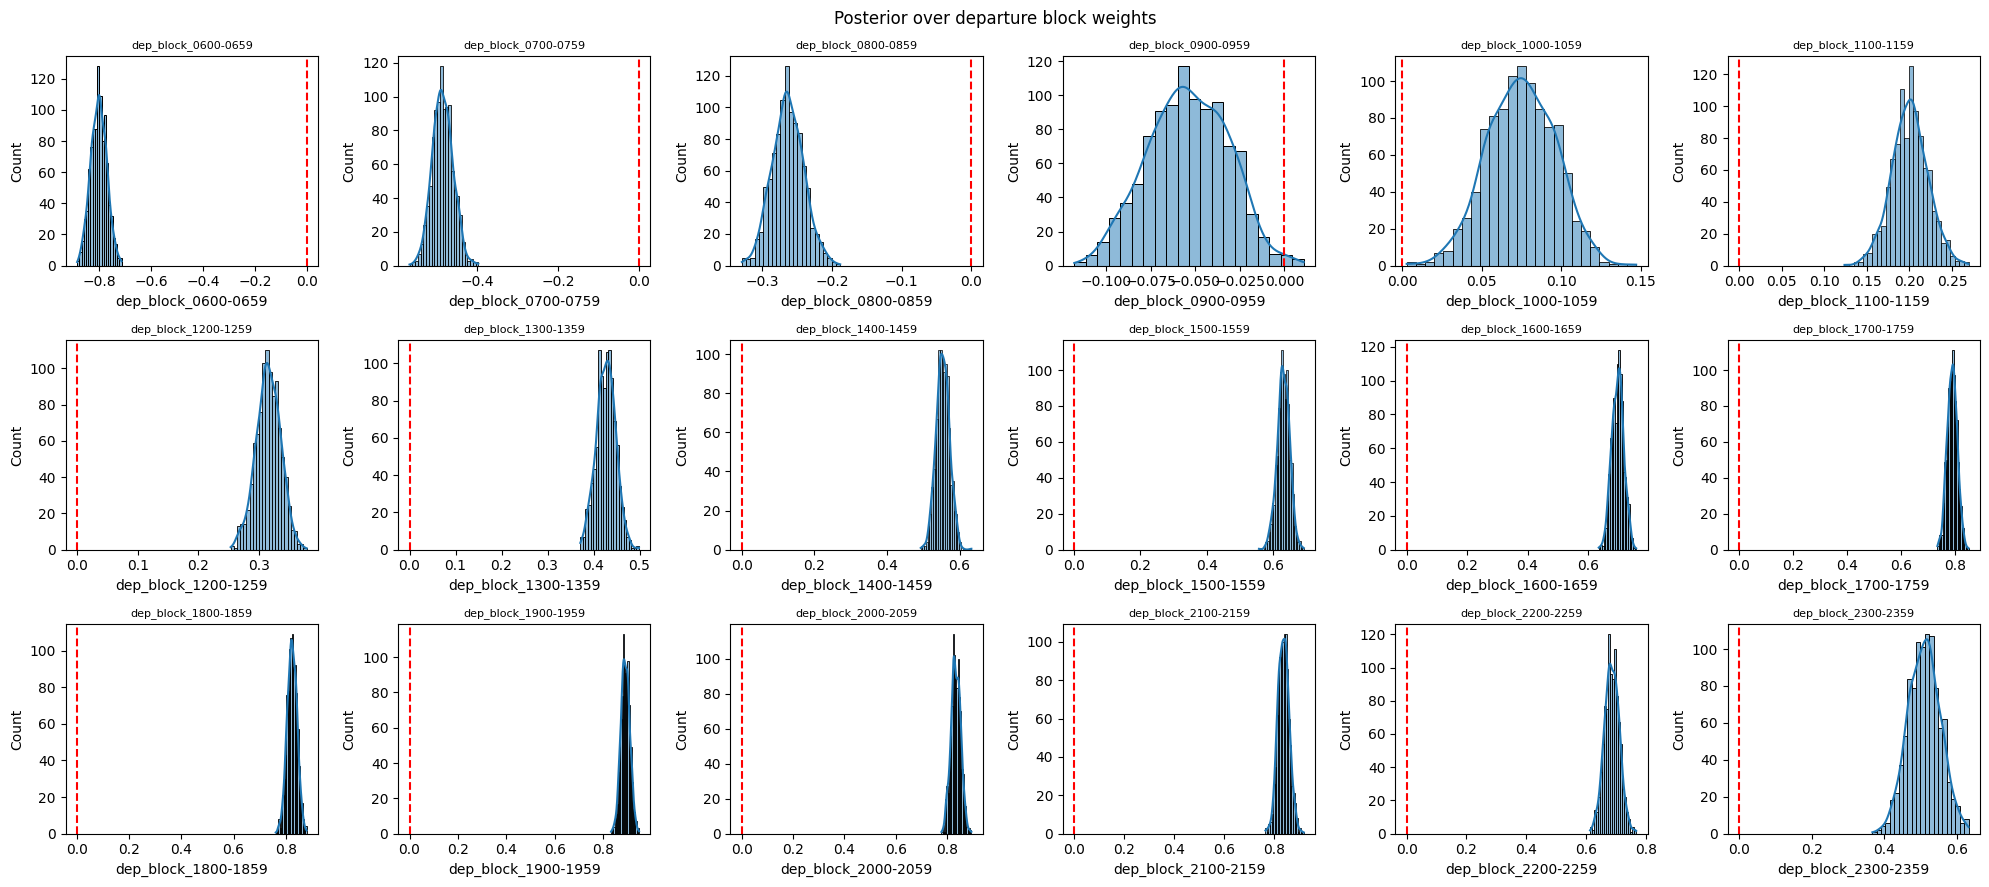

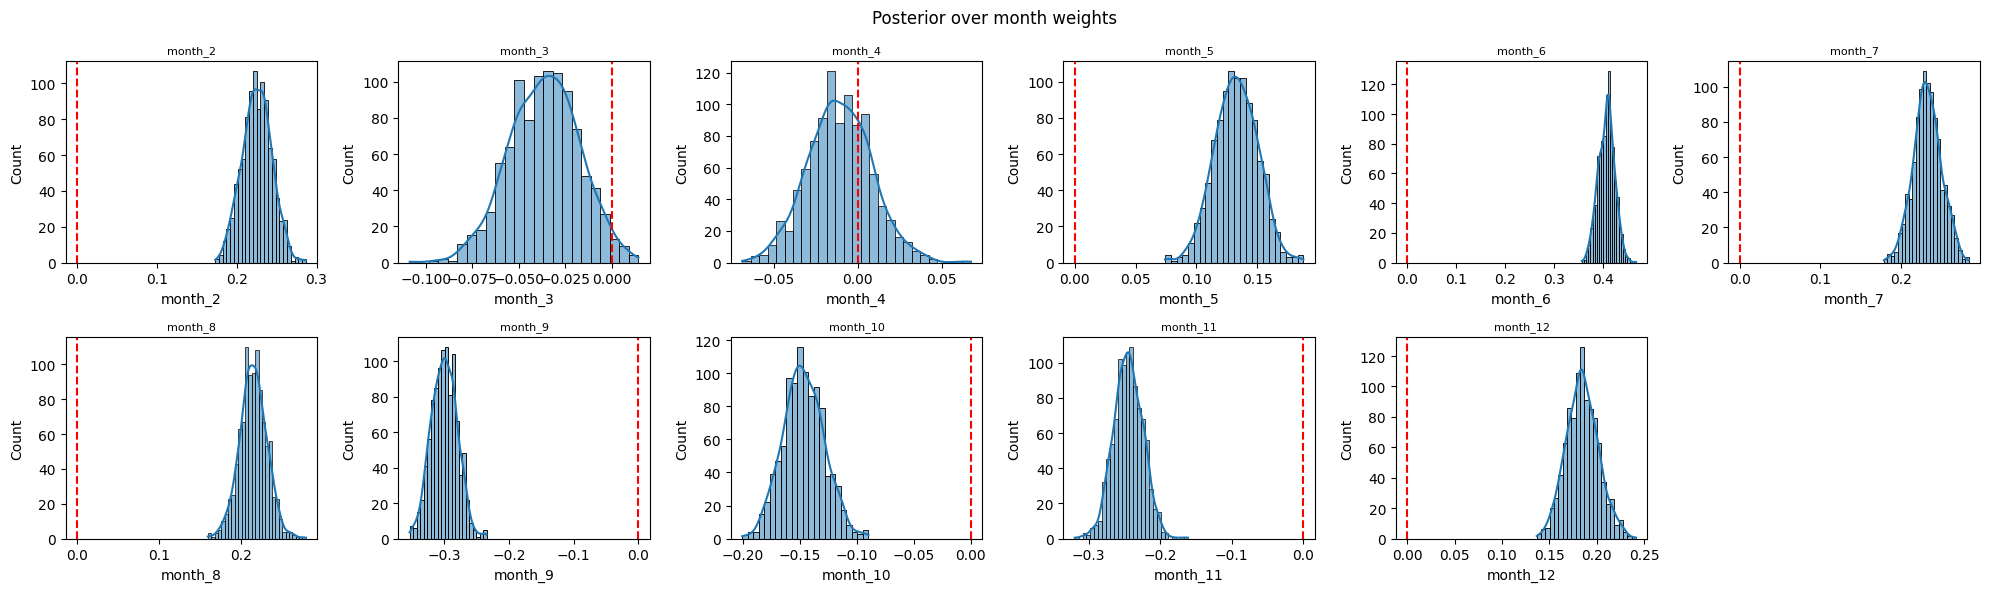

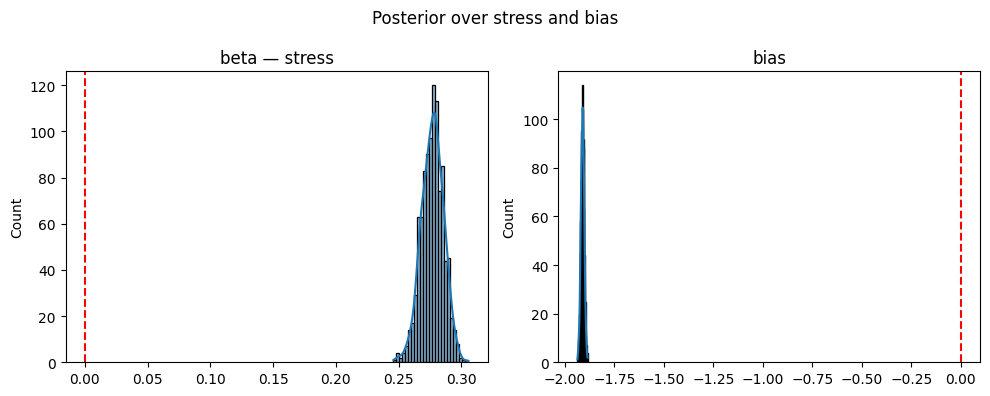

In [ ]:
w_samples    = samples1["w"].detach().squeeze(1).numpy()     # (1000, 18)
beta_samples = samples1["beta"].detach().squeeze(1).numpy()  # (1000, 32)
bias_samples = samples1["bias"].detach().squeeze(1).numpy()  # (1000,)

n_weather = X_weather_train.shape[1]  # 2
n_dept    = X_dept_train.shape[1]     # 18
n_month   = X_month_train.shape[1]    # 11

# ── stress weights ──
stress_cols1 = carrier_columns_model + ["PREV_AIRPORT_DELAY_RATE", "DEPARTING_AIRPORT_DELAY_RATE"]
w_df = pd.DataFrame(w_samples, columns=stress_cols1)

n_cols = len(stress_cols1)
n_rows = (n_cols + 5) // 6
fig, axes = plt.subplots(n_rows, 6, figsize=(20, n_rows*3))
axes = axes.flatten()
for i, col in enumerate(w_df.columns):
    sns.histplot(w_df[col], ax=axes[i], kde=True)
    axes[i].axvline(0, color="red", linestyle="--")
    axes[i].set_title(col, fontsize=8)
for j in range(i+1, len(axes)):
    axes[j].set_visible(False)
plt.suptitle("Posterior over stress weights")
plt.tight_layout()
plt.show()

# ── delay weights — rain and wind ──
fig, axes = plt.subplots(1, 2, figsize=(10, 4))
for i, (name, idx) in enumerate([("rain", 0), ("wind", 1)]):
    sns.histplot(beta_samples[:, idx], ax=axes[i], kde=True)
    axes[i].axvline(0, color="red", linestyle="--")
    axes[i].set_title(f"beta — {name}")
plt.suptitle("Posterior over weather weights")
plt.tight_layout()
plt.show()

# ── departure block weights ──
dept_df = pd.DataFrame(beta_samples[:, n_weather:n_weather+n_dept], columns=dpt_columns_model)
n_cols = len(dpt_columns_model)
n_rows = (n_cols + 5) // 6
fig, axes = plt.subplots(n_rows, 6, figsize=(20, n_rows*3))
axes = axes.flatten()
for i, col in enumerate(dept_df.columns):
    sns.histplot(dept_df[col], ax=axes[i], kde=True)
    axes[i].axvline(0, color="red", linestyle="--")
    axes[i].set_title(col, fontsize=8)
for j in range(i+1, len(axes)):
    axes[j].set_visible(False)
plt.suptitle("Posterior over departure block weights")
plt.tight_layout()
plt.show()

# ── month weights ──
month_df = pd.DataFrame(beta_samples[:, n_weather+n_dept:n_weather+n_dept+n_month], 
                         columns=month_columns_model)
n_cols = len(month_columns_model)
n_rows = (n_cols + 5) // 6
fig, axes = plt.subplots(n_rows, 6, figsize=(20, n_rows*3))
axes = axes.flatten()
for i, col in enumerate(month_df.columns):
    sns.histplot(month_df[col], ax=axes[i], kde=True)
    axes[i].axvline(0, color="red", linestyle="--")
    axes[i].set_title(col, fontsize=8)
for j in range(i+1, len(axes)):
    axes[j].set_visible(False)
plt.suptitle("Posterior over month weights")
plt.tight_layout()
plt.show()

# ── stress and bias ──
fig, axes = plt.subplots(1, 2, figsize=(10, 4))
sns.histplot(beta_samples[:, -1], ax=axes[0], kde=True)
axes[0].axvline(0, color="red", linestyle="--")
axes[0].set_title("beta — stress")

sns.histplot(bias_samples, ax=axes[1], kde=True)
axes[1].axvline(0, color="red", linestyle="--")
axes[1].set_title("bias")
plt.suptitle("Posterior over stress and bias")
plt.tight_layout()
plt.show()

In [ ]:
# get posterior means
w_mean    = w_samples.mean(axis=0)     # (18,)
beta_mean = beta_samples.mean(axis=0)  # (32,)
bias_mean = bias_samples.mean()        # scalar

n_weather = X_weather_train.shape[1]  # 2
n_dept    = X_dept_train.shape[1]     # 18
n_month   = X_month_train.shape[1]    # 11

# compute stress
stress_train = X_stress_train1.numpy() @ w_mean

# compute logits
logits_train = (
    (X_weather_train.numpy() * beta_mean[0:n_weather]).sum(axis=1) +
    (X_dept_train.numpy()    * beta_mean[n_weather:n_weather+n_dept]).sum(axis=1) +
    (X_month_train.numpy()   * beta_mean[n_weather+n_dept:n_weather+n_dept+n_month]).sum(axis=1) +
    beta_mean[-1] * stress_train +
    bias_mean
)

p_train = torch.sigmoid(torch.tensor(logits_train, dtype=torch.float32)).numpy()
y_fake  = np.random.binomial(1, p_train)

print("Real delay rate:", y_train.numpy().mean())
print("Fake delay rate:", y_fake.mean())

Real delay rate: 0.1891448
Fake delay rate: 0.1910623158988539


## Testing

In [ ]:
# get posterior means
w_mean    = w_samples.mean(axis=0)
beta_mean = beta_samples.mean(axis=0)
bias_mean = bias_samples.mean()

n_weather = X_weather_test.shape[1]   # 2
n_dept    = X_dept_test.shape[1]      # 18
n_month   = X_month_test.shape[1]     # 11

CHUNK = 10000
p_mean_list = []

for i in range(0, len(X_stress_test1), CHUNK):
    X_s = X_stress_test1[i:i+CHUNK].numpy()
    X_w = X_weather_test[i:i+CHUNK].numpy()
    X_d = X_dept_test[i:i+CHUNK].numpy()
    X_m = X_month_test[i:i+CHUNK].numpy()

    stress = X_s @ w_mean

    logits = (
        (X_w * beta_mean[0:n_weather]).sum(axis=1) +
        (X_d * beta_mean[n_weather:n_weather+n_dept]).sum(axis=1) +
        (X_m * beta_mean[n_weather+n_dept:n_weather+n_dept+n_month]).sum(axis=1) +
        beta_mean[-1] * stress +
        bias_mean
    )

    p = torch.sigmoid(torch.tensor(logits, dtype=torch.float32)).numpy()
    p_mean_list.append(p)

p_mean = np.concatenate(p_mean_list)
y_pred = (p_mean > 0.5).astype(float)

In [ ]:
y_test_np = y_test.numpy()

print("=== Test Evaluation ===")
print(f"Real delay rate:      {y_test_np.mean():.4f}")
print(f"Predicted delay rate: {y_pred.mean():.4f}")
print(f"Accuracy:  {accuracy_score(y_test_np, y_pred):.4f}")
print(f"AUC-ROC:   {roc_auc_score(y_test_np, p_mean):.4f}")
print(classification_report(y_test_np, y_pred))

=== Test Evaluation ===
Real delay rate:      0.1891
Predicted delay rate: 0.0046
Accuracy:  0.8112
AUC-ROC:   0.6605
              precision    recall  f1-score   support

         0.0       0.81      1.00      0.90   1578509
         1.0       0.54      0.01      0.03    368210

    accuracy                           0.81   1946719
   macro avg       0.68      0.51      0.46   1946719
weighted avg       0.76      0.81      0.73   1946719

